# APSIDE: TOV Component
## Written by: Liam Colombo-Murphy and M. Grant Roberts

You will only need to edit the variables in the last cell which are: "data_file" and "PCentral". The data_file is the path to your data and PCentral is the range of central pressures which you run the solver over. Please read the relevant comment above these variables for more information. The file format of your data should be "pressure, energy_density" - one row at a time. The code will automatically create an output file called "data_0" which contains the history of the rk4 solver. The code will also automatically create a mass versus radius plot for your given data_file. If you have multiple data files to run, you can simply just create a loop over a list of data file names and the code will output its results into files in the format "data_#" where # = the current data file, with the first data file starting at index of 0. 

In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from NaturalConstants import *

In [3]:
# Constants
tiny = 1e-20
G = 6.67408e-8       # dyne cm^2 / g^2
c = 2.99792458e+10   # cm/s   #SoL 

def plotter(txt = 'NS-MS1'):
    data = np.loadtxt( txt + '.txt')
    xdata = data[:, 0]
    ydata = data[:, 1]

    return xdata, ydata

def func(x, y, epsilon_interp):
    '''
    Gives TOV Equations to be solved by rk4 function
        k[0] = dm/dr
        k[1] = dP/dr
    '''
    k = np.zeros(len(y))
    
    # y[0] = mass(r)
    # y[1] = pressure(r)

    mass = y[0] + tiny
    pressure = y[1]
    epsilon = epsilon_interp(pressure)
    radius = x + tiny

    if epsilon <= 0 or np.isnan(epsilon):
        return np.zeros(len(y))  # Stop integration safely
    
    part1 = -1*G*mass*epsilon/(c**2*radius**2)
    part2 = 1.0 + pressure/epsilon
    part3 = 1.0 + 4*np.pi*pressure*radius**3/(c**2*mass)
    part4 = (1.0 - 2*G*mass/(c**2*radius))**(-1)
    
    dPdr = part1 * part2 * part3 * part4 

    k[0] = 4*np.pi*epsilon*radius**2/(c**2)               #dm/dr
    k[1] = dPdr                                           #again this is dP/dr
    
    return k


def rk4(a, b, alpha, N, data_label, epsilon_interp, pressure_cutoff = 1e-20):
    '''
    Runge-Kutta 4th Order Method
        t = scanning variable
        a, b such that a <= t <= b, a is radius of object's center, b should be greater than the star's surface radius
        alpha = inital condition y(a) = alpha, [m(r=0), P(r=0)]
        N = number of iterations
        epsilon_interp = eps(P), energy density as function of Pressure
    '''

    k1, k2, k3, k4, func_val = [], [], [], [], []
    
    t = a
    w = alpha
    h = (b - a) / N
    
    with open('data_'+str(data_label)+'.txt','w') as file:
        file.writelines([str(t),', ', str(w[0]),', ',str(w[1]),', ', str(h),'\n'])

    mass_lim = [w[0],]
    
    i = 1
    while( i < N ):
        k1 = h * func(t, w, epsilon_interp)
        k2 = h * func(t + h/2, w + k1/2, epsilon_interp)
        k3 = h * func(t + h/2, w + k2/2, epsilon_interp)
        k4 = h * func(t + h,   w + k3, epsilon_interp)

        t = a + i*h 
        w = w + (k1 + 2*k2 + 2*k3 + k4)/6.0
        x_val = t     # return the x_value              This gives the i'th radius
        func_val = w  # return the function_value       This gives your i'th mass then pressure in array, [m_i, P_i]

        mass_lim.append(func_val[0])
      
        if (func_val[1] > pressure_cutoff) and (func_val[0] > mass_lim[i-1]):
            with open('data_'+str(data_label)+'.txt','a') as file:
                file.writelines([str(x_val),', ', str(func_val[0]),', ',str(func_val[1]),', ', str(h),'\n']) #radius, mass, pressure, delta/step width
        
        else:                   
            break

        i+=1


def y_equation(r, y, R_dep):
    '''
    Inputs:
        r - radius in cm where current part of solution is being solved for
        y - differential parameter
        R_dep: 
            e_R - energy density profile as function of radius, 1/cm^2 
            P_R - pressure profile as function of radius, 1/cm^2
            m_R - enclosed mass at radius r, cm
    Outputs:
        dydr - differential in y and r, to be solved by solve_y
    
    ''' 
    eps_interp, P_interp, m_interp, dPde, surface_radius = R_dep
    
    if P_interp(r) <= 0:
        return 0  # Stop integration

    R = surface_radius
    P = P_interp(r)
    eps = eps_interp(r)
    m = m_interp(r)
    cs2 = dPde(r)
    

    if P <= 0 or r <= 0 or (1 - 2*m/r) <= 0:
        return 0  
        
    elambda = (1- 2*m/r)**(-1)
    nu_prime = 2*elambda * (m + 4*np.pi*r**3 * P)/(r**2)

    Q = 4*np.pi*elambda * (5*eps + 9*P + (eps+P)/cs2 ) - 6*elambda/(r**2) - (nu_prime)**2

    dydr = -1/r * (y**2 + y*elambda * (1 + 4*np.pi*r**2 * (P - eps) ) + r**2 * Q )

    return dydr

def solve_y(R_dep):
    '''
    Takes differential of y (dy/dr) defined in previous function and integrates it from the core to the surface of the object
    Then selects the value of yR = y(R) with R being R_surface. 
    '''
    eps_interp, P_interp, m_interp, dPde, surface_radius = R_dep

    R = surface_radius # cm
    sol_y = solve_ivp(y_equation, t_span = [1e-5, R], y0 = [2], args = [R_dep], method = 'RK45',) # args=(P_interp, eps_interp, cs2_interp, m_interp),
    yR = sol_y.y[0,-1]

    return yR

def y_equation_2(r, y, R_dep):
    '''
    Inputs:
        r - radius in cm where current part of solution is being solved for
        y - differential parameter
        R_dep: 
            e_R - energy density profile as function of radius, 1/cm^2 
            P_R - pressure profile as function of radius, 1/cm^2
            m_R - enclosed mass at radius r, cm
    Outputs:
        dydr - differential in y and r, to be solved by solve_y
    
    ''' 
    eps_interp, P_interp, m_interp, dPde, surface_radius = R_dep
    
    if P_interp(r) <= 0:
        return 0  # Stop integration

    R = surface_radius
    P = P_interp(r)
    eps = eps_interp(r)
    m = m_interp(r)
    cs2 = dPde(r)

    if P <= 0 or r <= 0 or (1 - 2*m/r) <= 0:
        return 0 

    dydr = -1/r * (y**2 + y - 6 + 4*np.pi*r**2 * eps/cs2 )

    return dydr

def solve_y_2(R_dep):
    '''
    Takes differential of y (dy/dr) defined in previous function and integrates it from the core to the surface of the object
    Then selects the value of yR = y(R) with R being R_surface. 
    '''
    eps_interp, P_interp, m_interp, dPde, surface_radius = R_dep

    R = surface_radius # cm
    sol_y = solve_ivp(y_equation_2, t_span = [1e-5, R], y0 = [2], args = [R_dep], method = 'RK45',) # args=(P_interp, eps_interp, cs2_interp, m_interp),
    yR = sol_y.y[0,-1]

    return yR

def solve_tidal(R_dep):
    '''
    Constants:
        R - surface radius in cm
        M - total mass of body in cm
        y - dimensionless parameter y solved in differential
    Outputs:
        R/1e5 - radius of body in km
        M/(Msun * 1e3) - mass of body in Msun
        C - compactness of body
        k2 - tidal love number k2
        y, beta, H - values used to calculate k2
    '''
    eps_interp, P_interp, m_interp, dPde, surface_radius = R_dep
    
    R = surface_radius       # in cm
    M = m_interp(R)          # in cm


    C = compactness = M/R
    
    if C >= 0.5:
        print("Warning: compactness >= 0.5 may lead to divergence in log(1-2C)")

    # For Strange Quark Objects, uncomment the term - 4*np.pi*R**3*eps_interp(R)/M
    if C > 0.1:
        y = solve_y([eps_interp, P_interp, m_interp, dPde, R]) - 4*np.pi*R**3*eps_interp(R)/M # uncomment second subtracting term for bare strange stars

        k2 = (8*C**5)/5 * (1 - 2*C)**2 *(2 + 2*C * (y - 1) - y) * (2*C * (6 - 3*y + 3*C * (5*y - 8)) + 4*C**3 * \
            (13 - 11*y + C * (3*y - 2) + 2*C**2 * (1 + y)) + 3 * (1 - 2*C)**2 * (2 - y + 2 * C * (y - 1)) * \
            (np.log(1 - 2 * C)) )**(-1)

    
    if C <= 0.1 and C > 1e-3:
        y = solve_y([eps_interp, P_interp, m_interp, dPde, R]) - 4*np.pi*R**3*eps_interp(R)/M # uncomment second subtracting term for bare strange stars

        k2 = 1/2*(1-2*C)**2 * ( (2-y)/(3+y) + (-6 + 6*y + y**2)*C/(3+y)**2 + (12 - 8*y + 34*y**2 + y**3) * \
            C**(2) /(7*(3+y)**3) + (36 + 48*y + 84*y**2 + 62*y**3 + y**4) * C**3/(7*(3+y)**4) + \
            5*(648 + 1476*y + 1884*y**2 + 1472*y**3 + 490*y**4 + 5*y**5) * C**4/(147*(3+y)**5) )

    
    if C <= 1e-3:
        y = solve_y_2([eps_interp, P_interp, m_interp, dPde, R]) - 4*np.pi*R**3*eps_interp(R)/M # uncomment second subtracting term for bare strange stars
        
        k2 = 1/2 * (2-y)/(3+y)

    return np.array([R/1e5 , M *c**2/G *1/ (MSun * 1e3), C, k2, y])#, beta, H])

In [4]:
# to start the solver, i need the central pressure and central energy density. to then create the next point i need
# the energy density as a function of pressure. i make the assumption that the data that is being read in from
# the data file is something of the form: pressure, energy_density(pressure) for each row. ie, the first column will
# have the pressure values, and the next column within the same row will have the energy_density as a function of that
# pressure value. the code does not need any pressure value aside from the central pressure, but the energy density 
# does. so what we do is we create an interpolation object in energy density and use that as our energy_density function
# for the code to use.

def plotter(txt = 'FileNamewithout_txt'):
    data = np.loadtxt( txt + '.txt')
    xdata = data[:, 0]
    ydata = data[:, 1]

    return xdata, ydata


def read_data(infile):
    '''
    Calls EOS file, the file must take the form: 
    Pressure [MeV/fm^3], Energy Density [MeV/fm^3] for the solver to work properly
    '''
    
    with open(infile,'r') as in_file:
        file = in_file.readlines()
        pressure_list = np.zeros(len(file))
        energy_density_list = np.zeros(len(file))
        
        for j in range(len(file)):
            pressure = float(file[j].split(',')[0])
            energy_density = float(file[j].split(',')[1].rstrip('\n'))
            
            pressure_list[j] = pressure
            energy_density_list[j] = energy_density
        
        print('units are given in: MeV/fm^3') 
        pressure_list = pressure_list/DyneCM2ToMeVfm3 
        energy_density_list = energy_density_list*MeVfm3ToErgcm3
        
        dP_de_vals = np.gradient(pressure_list, energy_density_list)
        
        plt.plot(energy_density_list*DyneCM2ToMeVfm3*1.78e12, pressure_list*DyneCM2ToMeVfm3, color = 'slateblue')

    
    plt.title('Equation of State for ' + str(infile))
    plt.xlabel(r'Energy Density $\epsilon [g/cm^3]$') #[MeV/fm^3]$') #[erg/cm^3]$')
    plt.ylabel(r'Pressure $P [MeV/fm^3]$') #[dyne/cm^2]$')
    plt.xscale('log')
    plt.yscale('log')

    plt.tight_layout()    
    plt.show()
    
    return pressure_list, energy_density_list
  

def main(PCentral, energy_density_interp_function, stepend = 25, stepcount = 1e3):
    a = 1e-20               #Starting radius of rk4, small but not zero to avoid possible division by zero
    b = stepend * 1e5       #This is the endpoint of the rk4 solver scanning range in cm, multiplying by 10^5 gives km, use 25e5 for SQS
    final_mass = []
    final_radius = []
    final_pressure = []

    final_k2 = []
    final_lambda = []
    final_compactness = []
    final_dimensionless_lambda = []
    
    for i in range(len(PCentral)):
        alpha = [0.0, PCentral[i]] #[m(r=0), P(r=0)]

        rk4(a, b, alpha, stepcount, i, energy_density_interp_function)
        #print('-------------------------------------')
        mass_array = []
        radius_array = []
        pressure_array = []
        
        geom_mass_array = []
        geom_radius_array = []
        geom_pressure_array = []
        geom_en_dens_array = []

        # r_surface = []
        # geom_final_pressure = []
        
        with open('data_'+str(i)+'.txt') as file:
            in_file = file.readlines()
            for j in range(len(in_file)):
                mass = float(in_file[j].split(',')[1].split()[0])
                pressure = float(in_file[j].split(',')[2].split()[0])
                radius = float(in_file[j].split(',')[0])
                en_dens = float(energy_density_interp(pressure)) #Usual
                
                mass_array.append(mass/1.989e33) # mass divided by Msol to give it in solar masses
                radius_array.append(radius/1e5 ) # km (hence the /1e5)
                pressure_array.append(pressure) # dyne/cm^2

                geom_mass_array.append(mass * G/c**2) # in units cm
                geom_radius_array.append(radius) # in units cm
                geom_pressure_array.append(pressure * G/c**4) #this is in 1/cm^2
                geom_en_dens_array.append(en_dens * G/c**4) #this is in 1/cm^2
                
            mass_holder = mass_array[-1]
            radius_holder = radius_array[-1]
            pressure_holder = pressure_array[-1]

            geom_mass_holder = geom_mass_array[-1]
            geom_radius_holder = geom_radius_array[-1]
            geom_pressure_holder = geom_pressure_array[-1]
            
            final_mass.append(mass_holder)
            final_radius.append(radius_holder)
            final_pressure.append(pressure_holder)

            if len(geom_radius_array) < 4:
                print(f"Not enough points to interpolate for model {i}")
                continue

            e_R = interp1d(geom_radius_array, geom_en_dens_array, kind='cubic')                      
            P_R = interp1d(geom_radius_array, geom_pressure_array, kind='cubic', bounds_error=True)   
            m_R = interp1d(geom_radius_array, geom_mass_array, kind='cubic', bounds_error=True)

            dP_de = np.gradient(P_R(geom_radius_array), e_R(geom_radius_array))
            dPde_r = interp1d(geom_radius_array, dP_de, kind = 'cubic')


            Radius_body, Mass_msun, Compactness, k2, y = solve_tidal([e_R, P_R, m_R, dPde_r, geom_radius_holder])

            tidal_lambda = 2*geom_radius_holder**5/(3*6.6743e-8) * k2


            dimensionless_lambda = 2/3 * k2*(1/Compactness)**5

            final_k2.append(k2)
            final_lambda.append(tidal_lambda)
            final_compactness.append(Compactness)
            final_dimensionless_lambda.append(dimensionless_lambda)
    
            plt.plot(radius_array, mass_array)

        if not np.all(np.diff(geom_radius_array) > 0):
            print("Warning: radius array is not strictly increasing!")
        
    plt.title('Each mass-radius curve for a specific central density')
    plt.xlabel(r'R (km)')
    plt.ylabel(r'$M~(M_{\odot})$')
    # plt.xscale('log')
    # plt.yscale('log')
    plt.show()


    if (len(PCentral) > 1):

        # 2x2 Plot of Mass-Radius, Mass-k2, and Mass-Tidal Deformabilities
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 7),)
        
        # Plot on the first subplot (top-left)
        axes[0, 0].plot(np.array(final_mass)*1.989e33/1.898e30, np.array(final_radius), '-', color = 'darkturquoise')
        
        axes[0, 0].set_ylabel(r'R (km)')
        axes[0, 0].set_xlabel(r'M $(M_{J})$')
        axes[0, 0].set_xscale('log')
        axes[0, 0].set_yscale('log')
        
        
        # Plot on the second subplot (top-right)
        axes[0, 1].plot(np.array(final_mass)*1.989e33/1.898e30, final_k2, linestyle = '-', color = 'darkturquoise')
        
        axes[0, 1].set_ylabel(r'$k_{2}$')
        axes[0, 1].set_xlabel(r'$M~(M_{J})$')
        axes[0, 1].set_xscale('log')

        
        # Plot on the third subplot (bottom-left)
        axes[1, 0].plot(np.array(final_mass)*1.989e33/1.898e30, np.array(final_lambda)*c**10/(G**4 * np.array(final_mass)**5), '-', color = 'darkturquoise')

        axes[1, 0].set_ylabel(r'$\Lambda$')
        axes[1, 0].set_xlabel(r'M $(M_{J})$')
        axes[1, 0].set_yscale('log')
        axes[1, 0].set_xscale('log')

        
        # Plot on the fourth subplot (bottom-right)
        axes[1, 1].plot(np.array(final_mass)*1.989e33/1.898e30, np.array(final_lambda), '-', color = 'darkturquoise')
 
        axes[1, 1].set_ylabel(r'$\lambda~(\text{g} \text{cm}^2 \text{s}^2)$')
        axes[1, 1].set_xlabel(r'$M~(M_{J})$')
        axes[1, 1].set_yscale('log')
        axes[1, 1].set_xscale('log')

        plt.tight_layout()
        plt.show()

        # Save Arrays
        EOSname = 'SQS'
        # np.savetxt(str(EOSname) + '_masses.txt', np.array(final_mass)*1.898e33, delimiter=" ")
        # np.savetxt(str(EOSname) + '_radii.txt', np.array(final_radius)*1e5, delimiter=" ")
        # np.savetxt(str(EOSname) + '_k2s.txt', np.array(final_k2), delimiter=" ")
        # np.savetxt(str(EOSname) + '_lambdas.txt', np.array(final_lambda), delimiter=" ")

# List of Some Equations of State:

#### EOS Name $\in$ [A Good PCentral range]:

*It can be helful to increase step count to push to lower central pressures* \
SLy_EOS-(MeVfm^3)      $~~~\in~ $[8e-1* 1/DyneCM2ToMeVfm3, 1e3 * 1/DyneCM2ToMeVfm3]   \
eosstrange57           $~~~\in~ $[1e-3* 1/DyneCM2ToMeVfm3, 4.5e3 * 1/DyneCM2ToMeVfm3]   \
as well as eosstrange65,70,75,80,85,90

units are given in: MeV/fm^3


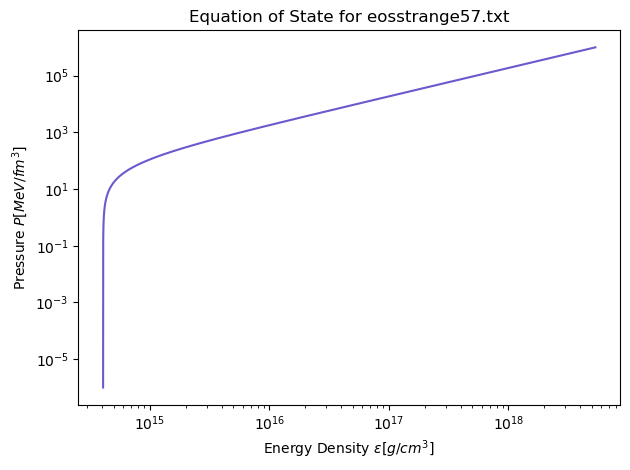

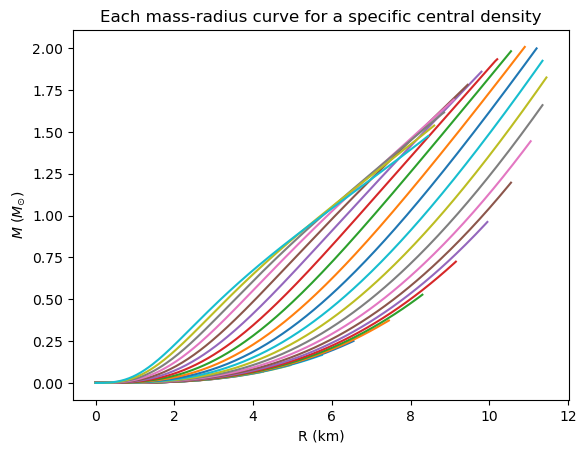

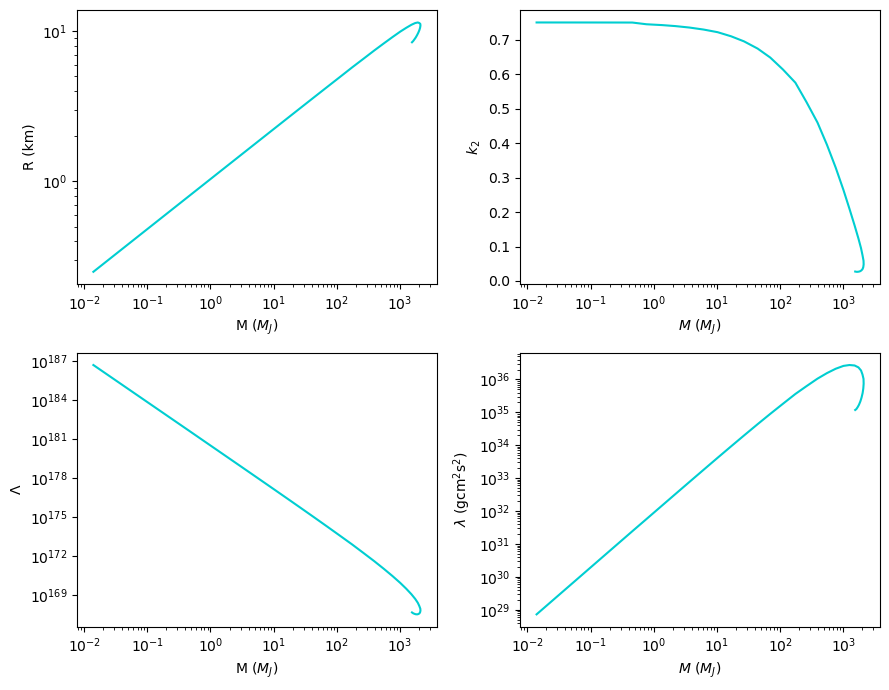

In [6]:
# This is the only piece of the code you need to edit. 
# data_file = the path to the file that has your pressure/energy_density values
# PCentral = range of central pressures solver runs over
# ---------------------------------------------------------------------
data_file = 'eosstrange57.txt'
PCentral = np.geomspace(1e-2* 1/DyneCM2ToMeVfm3, 4.5e3 * 1/DyneCM2ToMeVfm3, 40) 
# ---------------------------------------------------------------------

pressure_data, energy_density_data = read_data(data_file)
energy_density_interp = interp1d(pressure_data, energy_density_data, bounds_error=False, fill_value="extrapolate", kind='cubic') #gives eps(P) in CGS

main(PCentral, energy_density_interp, 50, 1e3) # Range of Central Pressures, Density interpolation function, Max Radius, Step Count (increase for precision at cost of runtime)